In [40]:
import argparse
import torch
from torch import nn, Tensor, optim
from typing import Optional, Union, Tuple, List, Any
import torch.optim as optim
from torch.ao.quantization import QuantStub, DeQuantStub
from torch.nn.quantized import FloatFunctional


import os
import json
import random
import numpy as np
from torch.utils.data import Dataset, DataLoader, RandomSampler
from torchvision import transforms
from PIL import Image
from tqdm import tqdm
from pycocotools.coco import COCO
import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode
import matplotlib.pyplot as plt
import torchvision.transforms as T

from cv_nets.utils.config_helper import get_param
from cv_nets.layers.activation import build_activation_layer
from cv_nets.layers.normalization import build_normalization_layer
from cv_nets.layers.pooling import build_pooling_layer
from cv_nets.layers import *

In [41]:
IMAGE_SIZE = (320, 320)
BATCH_SIZE = 16
NUM_WORKERS = 16
EPOCH = 150


TRAIN_IMG_DIR = './COCO/train2017'
TRAIN_ANN_FILE = './COCO/annotations/instances_train2017.json'

VAL_IMG_DIR = './COCO/val2017'
VAL_ANN_FILE = './COCO/annotations/instances_val2017.json'

SAVE_MODEL_DIR = './models/unet_base'

patience = 15                 # Số lượng epoch tối đa không giảm val_loss trước khi dừng
min_epochs_before_stop = 30  # Chỉ bắt đầu xét Early Stopping khi qua mốc này

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Đang sử dụng thiết bị: {device}")


Đang sử dụng thiết bị: cuda


In [42]:
class DoubleConvBlock(nn.Module):
    def __init__(self, opts: Any, in_channels: int, out_channels: int) -> None:
        super().__init__()
        self.conv1 = Conv2d(
            in_channels=in_channels, 
            out_channels=out_channels, 
            kernel_size=3, 
            stride=1, 
            padding=1, 
            opts=opts
        )
        self.norm1 = build_normalization_layer(opts, num_features=out_channels)
        self.act1 = build_activation_layer(opts)
        self.conv2 = Conv2d(
            in_channels=out_channels, 
            out_channels=out_channels, 
            kernel_size=3, 
            stride=1, 
            padding=1, 
            opts=opts
        )
        self.norm2 = build_normalization_layer(opts, num_features=out_channels)
        self.act2 = build_activation_layer(opts)

    def forward(self, x: Tensor) -> Tensor:
        x = self.act1(self.norm1(self.conv1(x)))
        x = self.act2(self.norm2(self.conv2(x)))
        return x


class UNetLite(nn.Module):
    def __init__(self, opts: Any = None, num_classes: int = 1) -> None:
        super().__init__()
        features = [16, 32, 64, 128]
        self.quant = QuantStub()
        self.dequant = DeQuantStub()
        self.f_cat = FloatFunctional()

        self.encoder_blocks = nn.ModuleList()
        self.downsample_layers = nn.ModuleList()
        
        in_ch = 3 
        for feat in features:
            self.encoder_blocks.append(DoubleConvBlock(opts, in_ch, feat))
            self.downsample_layers.append(
                Conv2d(in_channels=feat, out_channels=feat, kernel_size=2, stride=2, padding=0, opts=opts)
            )
            in_ch = feat
            
        self.bottleneck = DoubleConvBlock(opts, features[-1], features[-1] * 2) 

        self.decoder_blocks = nn.ModuleList()
        self.upsample_layers = nn.ModuleList()
        
        for feat in reversed(features):
            self.upsample_layers.append(
                ConvTranspose2d(in_channels=feat * 2, out_channels=feat, kernel_size=2, stride=2, padding=0, opts=opts)
            )
            self.decoder_blocks.append(DoubleConvBlock(opts, feat * 2, feat))

        self.final_conv = Conv2d(in_channels=features[0], out_channels=num_classes, kernel_size=1, stride=1, padding=0, opts=opts)

    def forward(self, x: Tensor) -> Tensor:
        x = self.quant(x)

        skip_connections: List[Tensor] = []
        
        for i in range(len(self.encoder_blocks)):
            x = self.encoder_blocks[i](x)
            skip_connections.append(x)  
            x = self.downsample_layers[i](x)
            
        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]
        
        for i in range(len(self.decoder_blocks)):
            x = self.upsample_layers[i](x)     
            skip_connection = skip_connections[i] 
            x_cat = self.f_cat.cat((skip_connection, x), dim=1)
            x = self.decoder_blocks[i](x_cat)   
            
        x = self.final_conv(x)
        x = self.dequant(x)
        return x


In [43]:
model = UNetLite(num_classes= 1)
print(model)

UNetLite(
  (quant): QuantStub()
  (dequant): DeQuantStub()
  (f_cat): FloatFunctional(
    (activation_post_process): Identity()
  )
  (encoder_blocks): ModuleList(
    (0): DoubleConvBlock(
      (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (norm1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act1): ReLU : inplace False
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (norm2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act2): ReLU : inplace False
    )
    (1): DoubleConvBlock(
      (conv1): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (norm1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act1): ReLU : inplace False
      (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (norm2): 

In [44]:
class COCOPersonDataset(Dataset):
    """
    Dataset tùy chỉnh với Data Augmentation đồng bộ (Resize cạnh ngắn -> Random Crop)
    """
    def __init__(self, img_dir, ann_file, image_size=IMAGE_SIZE, is_train=True):
        self.img_dir = img_dir
        self.coco = COCO(ann_file)
        self.image_size = image_size
        self.is_train = is_train 
        
        self.person_cat_id = self.coco.getCatIds(catNms=['person'])[0]
        self.img_ids = self.coco.getImgIds(catIds=[self.person_cat_id])

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, idx):
        img_id = self.img_ids[idx]
        img_info = self.coco.loadImgs(img_id)[0]
        img_path = os.path.join(self.img_dir, img_info['file_name'])
        image = Image.open(img_path).convert('RGB')
        
        ann_ids = self.coco.getAnnIds(imgIds=img_id, catIds=[self.person_cat_id], iscrowd=None)
        anns = self.coco.loadAnns(ann_ids)
        
        mask = np.zeros((img_info['height'], img_info['width']), dtype=np.uint8)
        for ann in anns:
            mask = np.maximum(mask, self.coco.annToMask(ann))
        mask = Image.fromarray(mask * 255).convert('L')

        if self.is_train:
            # 1. Random Scale: Đổi kích thước cạnh ngắn ngẫu nhiên thay vì cố định
            # Ví dụ: Kích thước thật là 320, ta scale ngẫu nhiên từ 320 đến 480
            short_edge = random.randint(min(self.image_size), int(min(self.image_size) * 1.5))
            image = TF.resize(image, short_edge, interpolation=InterpolationMode.BILINEAR)
            mask = TF.resize(mask, short_edge, interpolation=InterpolationMode.NEAREST)

            # 2. Random Rotation: Xoay ngẫu nhiên từ -15 đến 15 độ
            if random.random() > 0.5:
                angle = random.uniform(-15, 15)
                image = TF.rotate(image, angle, interpolation=InterpolationMode.BILINEAR)
                mask = TF.rotate(mask, angle, interpolation=InterpolationMode.NEAREST)

            # 3. Random Crop (Như cũ của bạn)
            i, j, h, w = T.RandomCrop.get_params(image, output_size=self.image_size)
            image = TF.crop(image, i, j, h, w)
            mask = TF.crop(mask, i, j, h, w)
            
            # 4. Random Horizontal Flip (Như cũ)
            if random.random() > 0.5:
                image = TF.hflip(image)
                mask = TF.hflip(mask)

            # 5. Color Jitter (Chỉ áp dụng cho Image, KHÔNG áp dụng cho Mask)
            if random.random() > 0.5:
                # Bạn có thể định nghĩa T.ColorJitter ở __init__ để code gọn hơn
                jitter = T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1)
                image = jitter(image)
                
            # 6. Gaussian Blur (Chỉ áp dụng cho Image)
            if random.random() > 0.7: # Tỷ lệ thấp thôi, vì ảnh mờ quá cũng không tốt
                blur_transform = T.GaussianBlur(kernel_size=(3, 5), sigma=(0.1, 2.0))
                image = blur_transform(image)

        else:
            # Quy trình cho tập Validation giữ nguyên
            short_edge = min(self.image_size)
            image = TF.resize(image, short_edge, interpolation=InterpolationMode.BILINEAR)
            mask = TF.resize(mask, short_edge, interpolation=InterpolationMode.NEAREST)
            image = TF.center_crop(image, self.image_size)
            mask = TF.center_crop(mask, self.image_size)

        # Chuyển thành Tensor và Normalize
        image_tensor = TF.to_tensor(image)
        image_tensor = TF.normalize(image_tensor, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        
        mask_tensor = TF.to_tensor(mask) 
        
        return image_tensor, mask_tensor

In [45]:
def calculate_iou(preds, masks, threshold=0.5):
    """Tính Intersection over Union (IoU) cho Segmentation"""
    preds = torch.sigmoid(preds) > threshold
    masks = masks > threshold
    
    intersection = (preds & masks).float().sum((1, 2, 3))
    union = (preds | masks).float().sum((1, 2, 3))
    
    iou = (intersection + 1e-6) / (union + 1e-6)
    return iou.mean().item()

In [46]:
def visualize_datasets(dataloader, num_samples=8):
    """
    Trực quan hóa kết quả dự đoán của mô hình Segmentation.
    Mỗi sample hiển thị: Ảnh gốc | Ground Truth | Prediction.
    """
    
    samples_shown = 0
    fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(20, 14))
    plt.subplots_adjust(wspace=0.1, hspace=0.3)
    
    inv_normalize = transforms.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )

    with torch.no_grad():
        for images, masks in dataloader:

            for i in range(images.size(0)):
                if samples_shown >= num_samples:
                    break
                
                row = samples_shown // 2
                col_offset = (samples_shown % 2) * 2

                img = inv_normalize(images[i]).permute(1, 2, 0).numpy()
                img = np.clip(img, 0, 1)

                gt_mask = masks[i].squeeze().numpy()

                ax_img = axes[row, col_offset]
                ax_img.imshow(img)
                ax_img.set_title(f"Sample {samples_shown+1}: Image")
                ax_img.axis('off')
                ax_gt = axes[row, col_offset + 1]
                ax_gt.imshow(gt_mask, cmap='gray')
                ax_gt.set_title("Ground Truth")
                ax_gt.axis('off')

                samples_shown += 1

            if samples_shown >= num_samples:
                break

    plt.suptitle("Dữ liệu mẫu Segmentation (Input | Ground Truth)", fontsize=16, y=0.92)
    plt.show()

In [47]:
print("Đang tải COCO Train Annotations...")
train_dataset = COCOPersonDataset(TRAIN_IMG_DIR, TRAIN_ANN_FILE, image_size=(320, 320))

Đang tải COCO Train Annotations...
loading annotations into memory...
Done (t=12.33s)
creating index...
index created!


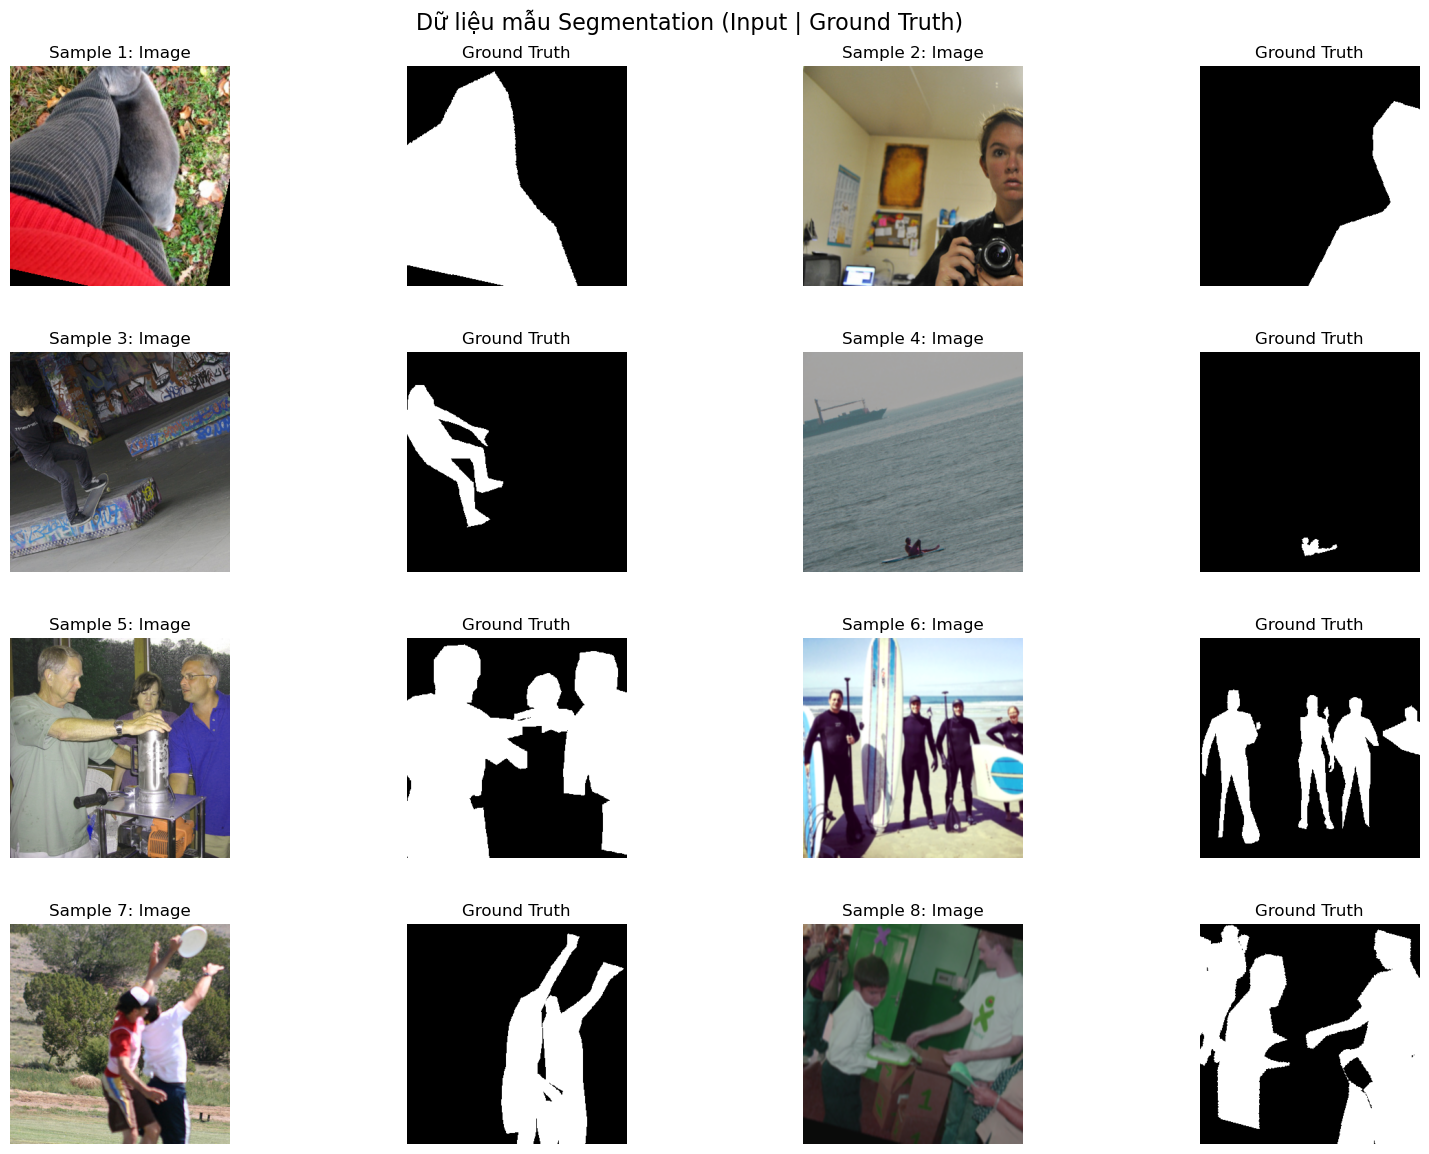

In [48]:
train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=NUM_WORKERS,  
    pin_memory=True 
)

visualize_datasets(train_loader)

In [49]:
print("Đang tải COCO Val Annotations...")
val_dataset = COCOPersonDataset(VAL_IMG_DIR, VAL_ANN_FILE, image_size=(320, 320), is_train = False)

Đang tải COCO Val Annotations...
loading annotations into memory...
Done (t=0.27s)
creating index...
index created!


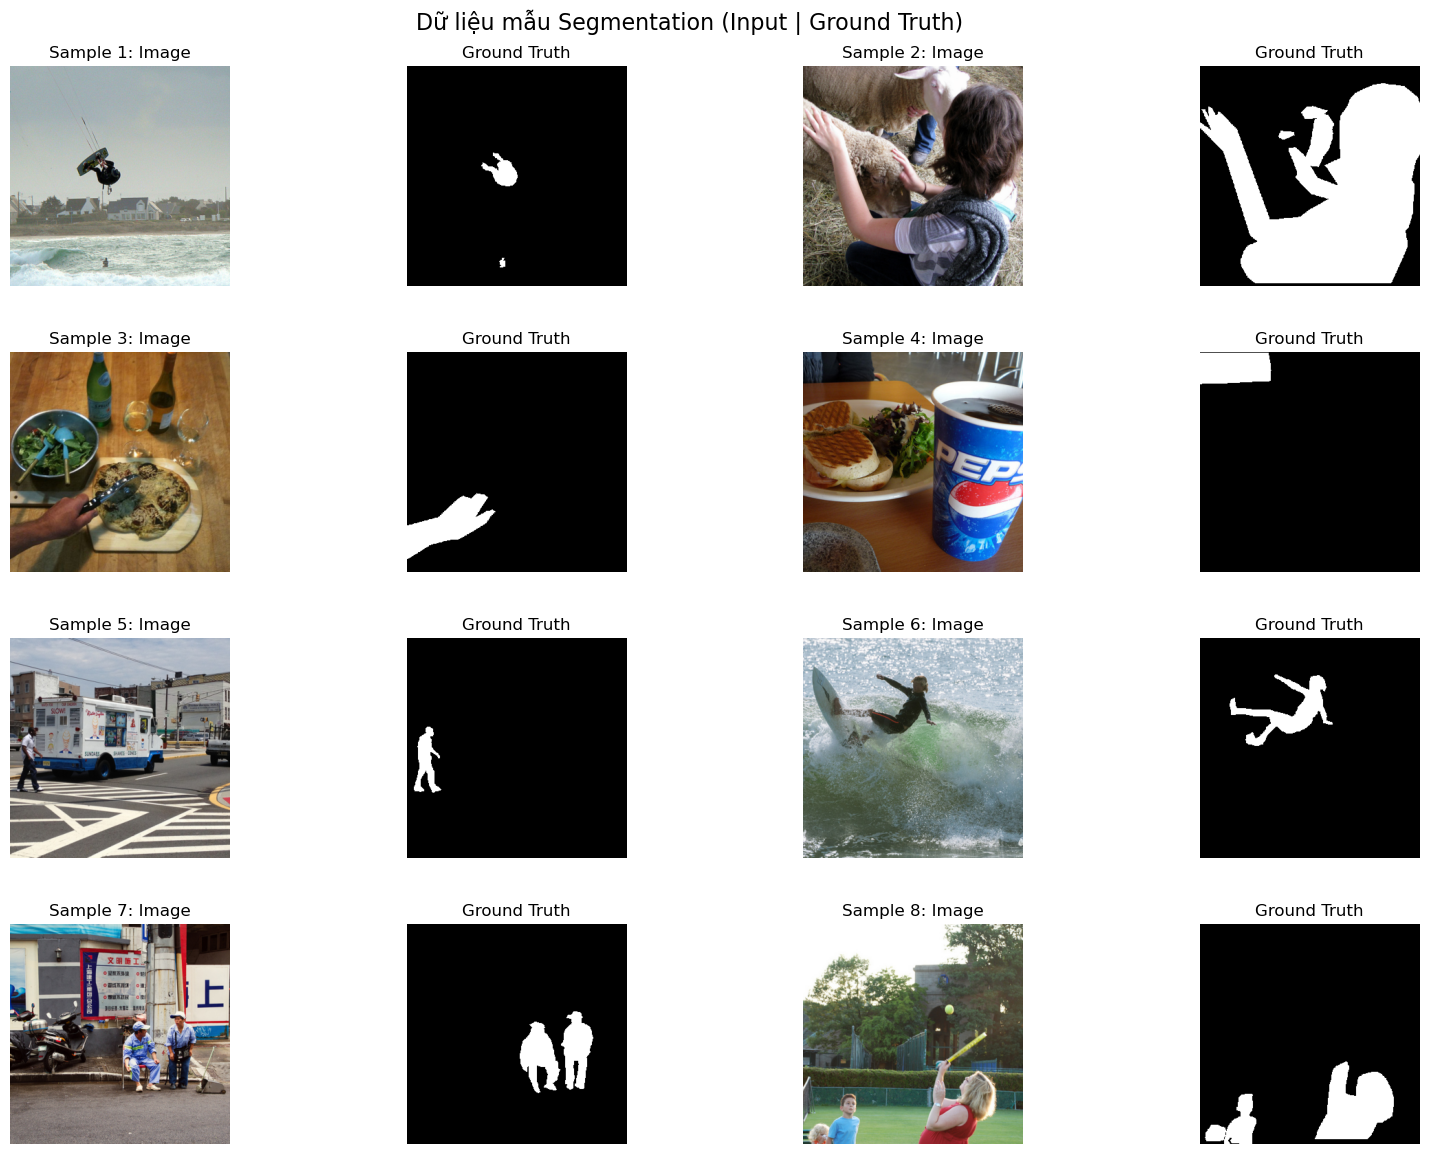

In [50]:
val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False,
    num_workers=NUM_WORKERS,  
    pin_memory=True 
)
visualize_datasets(val_loader)

In [51]:
print(f"Tìm thấy {len(train_dataset)} ảnh Train và {len(val_dataset)} ảnh Val chứa người.")

Tìm thấy 64115 ảnh Train và 2693 ảnh Val chứa người.


In [52]:

model = model.to(device)

scaler = torch.cuda.amp.GradScaler(enabled=device.type == 'cuda')
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

best_val_loss = float('inf')

history = {
    'train_loss': [],
    'val_loss': [],
    'val_iou': []
}
early_stop_counter = 0       

/tmp/ipykernel_113298/3226379831.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=device.type == 'cuda')


In [ ]:
for epoch in range(EPOCH):
    model.train()
    train_loss = 0.0
    
    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCH} [Train]", unit="batch")
    for images, masks in train_bar:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=device.type == 'cuda'):
            outputs = model(images)
            loss = criterion(outputs, masks)
            
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()
        train_bar.set_postfix(loss=f"{loss.item():.4f}")

    avg_train_loss = train_loss / len(train_loader)

    model.eval()
    val_loss = 0.0
    val_iou = 0.0
    
    val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCH} [Val]", unit="batch", leave=False)
    with torch.no_grad():
        for images, masks in val_bar:
            images = images.to(device)
            masks = masks.to(device)

            with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=device.type == 'cuda'):
                outputs = model(images)
                loss = criterion(outputs, masks)

            val_loss += loss.item()
            val_iou += calculate_iou(outputs, masks)

    avg_val_loss = val_loss / len(val_loader)
    avg_val_iou = val_iou / len(val_loader)
    
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['val_iou'].append(avg_val_iou)

    print(f"-> Epoch {epoch+1} Kết thúc | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val IoU: {avg_val_iou:.4f}")
    

    checkpoint_state = {
        'epoch': epoch + 1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'val_loss': avg_val_loss,
        'val_iou': avg_val_iou,
        'history': history  
    }
    last_save = os.path.join(SAVE_MODEL_DIR, "last_unet_base.pth")
    
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        early_stop_counter = 0 
        
        best_save = os.path.join(SAVE_MODEL_DIR, "best_unet_base.pth")
        torch.save(checkpoint_state, best_save)
        print(f"Đã cập nhật mô hình tốt nhất tại: {best_save}\n")
    else:
        print("\n")
        if (epoch + 1) > min_epochs_before_stop:
            early_stop_counter += 1
            print(f"[Cảnh báo] Validation Loss không giảm. Lần {early_stop_counter}/{patience} (Early Stopping)")
            if early_stop_counter >= patience:
                print(f"==== EARLY STOPPING KÍCH HOẠT: Dừng huấn luyện sớm tại Epoch {epoch+1} ====")
                torch.save(checkpoint_state, last_save)
                break
                
    torch.save(checkpoint_state, last_save)

Epoch 1/150 [Train]: 100%|██████████| 4008/4008 [08:33<00:00,  7.81batch/s, loss=0.3586]


-> Epoch 1 Kết thúc | Train Loss: 0.3858 | Val Loss: 0.2927 | Val IoU: 0.3220
Đã cập nhật mô hình tốt nhất tại: ./models/unet_base/best_unet_base.pth



Epoch 2/150 [Train]: 100%|██████████| 4008/4008 [08:26<00:00,  7.92batch/s, loss=0.3382]


-> Epoch 2 Kết thúc | Train Loss: 0.3161 | Val Loss: 0.2516 | Val IoU: 0.3864
Đã cập nhật mô hình tốt nhất tại: ./models/unet_base/best_unet_base.pth



Epoch 3/150 [Train]: 100%|██████████| 4008/4008 [08:22<00:00,  7.97batch/s, loss=0.4812]


...

-> Epoch 83 Kết thúc | Train Loss: 0.1358 | Val Loss: 0.1239 | Val IoU: 0.6414


[Cảnh báo] Validation Loss không giảm. Lần 1/15 (Early Stopping)


Epoch 84/150 [Train]: 100%|██████████| 4008/4008 [08:20<00:00,  8.01batch/s, loss=0.2117]


-> Epoch 84 Kết thúc | Train Loss: 0.1348 | Val Loss: 0.1229 | Val IoU: 0.6341
Đã cập nhật mô hình tốt nhất tại: ./models/unet_base/best_unet_base.pth



Epoch 85/150 [Train]:   4%|▎         | 148/4008 [00:23<10:03,  6.40batch/s, loss=0.1208]


KeyboardInterrupt: 

In [54]:
train_his_file = os.path.join(SAVE_MODEL_DIR, "training_history.json")
with open(train_his_file, "w") as f:
    json.dump(history, f, indent=4)
print(f"\nQuá trình huấn luyện hoàn tất! Đã xuất {train_his_file}.")


Quá trình huấn luyện hoàn tất! Đã xuất ./models/unet_base/training_history.json.


In [55]:
def plot_training_history(history_source):
    """
    Hàm vẽ biểu đồ Loss và IoU từ quá trình huấn luyện.
    
    Tham số:
    history_source: Có thể là dictionary `history` hoặc đường dẫn string tới file JSON.
    """
    if isinstance(history_source, str) and os.path.exists(history_source):
        print(f"Đang đọc dữ liệu từ file: {history_source}")
        with open(history_source, "r") as f:
            history = json.load(f)
    elif isinstance(history_source, dict):
        history = history_source
    else:
        raise ValueError("Đầu vào phải là dictionary 'history' hoặc đường dẫn tới file JSON.")

    train_loss = history.get('train_loss', [])
    val_loss = history.get('val_loss', [])
    val_iou = history.get('val_iou', [])
    
    epochs = range(1, len(train_loss) + 1)
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_loss, 'b-', label='Train Loss', linewidth=2)
    plt.plot(epochs, val_loss, 'r-', label='Validation Loss', linewidth=2)
    plt.title('Training and Validation Loss', fontsize=14)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, val_iou, 'g-', label='Validation IoU', linewidth=2)
    plt.title('Validation IoU', fontsize=14)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('IoU Score', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

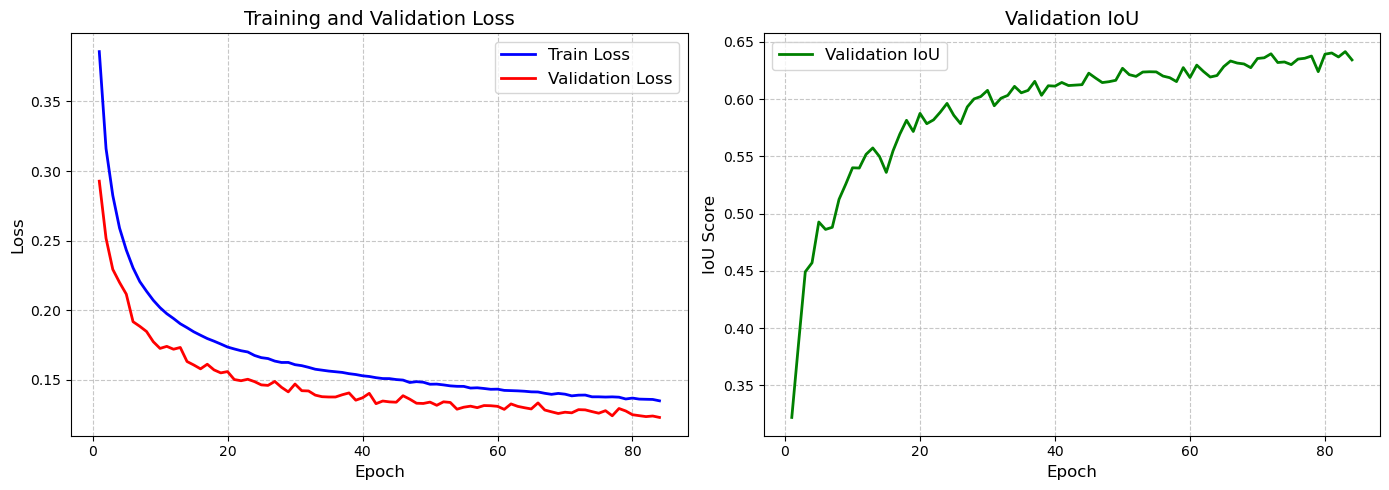

In [56]:
plot_training_history(history)

In [57]:
def visualize_predictions(model, dataloader, device, num_samples=8):
    """
    Trực quan hóa kết quả dự đoán của mô hình Segmentation.
    Mỗi sample hiển thị: Ảnh gốc | Ground Truth | Prediction.
    """
    model.eval()
    samples_shown = 0
    
    fig, axes = plt.subplots(nrows=4, ncols=6, figsize=(20, 14))
    plt.subplots_adjust(wspace=0.1, hspace=0.3)
    inv_normalize = transforms.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )

    with torch.no_grad():
        for images, masks in dataloader:
            images = images.to(device)
            masks = masks.to(device)
            with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=device.type == 'cuda'):
                outputs = model(images)
            preds = torch.sigmoid(outputs) > 0.5
            images = images.cpu()
            masks = masks.cpu()
            preds = preds.cpu()

            for i in range(images.size(0)):
                if samples_shown >= num_samples:
                    break
                row = samples_shown // 2
                col_offset = (samples_shown % 2) * 3
                img = inv_normalize(images[i]).permute(1, 2, 0).numpy()
                gt_mask = masks[i].squeeze().numpy()
                pred_mask = preds[i].squeeze().numpy()

                ax_img = axes[row, col_offset]
                ax_img.imshow(img)
                ax_img.set_title(f"Sample {samples_shown+1}: Image")
                ax_img.axis('off')

                ax_gt = axes[row, col_offset + 1]
                ax_gt.imshow(gt_mask, cmap='gray')
                ax_gt.set_title("Ground Truth")
                ax_gt.axis('off')

                ax_pred = axes[row, col_offset + 2]
                ax_pred.imshow(pred_mask, cmap='gray')
                ax_pred.set_title("Prediction")
                ax_pred.axis('off')

                samples_shown += 1

            if samples_shown >= num_samples:
                break

    plt.suptitle("Đánh giá mô hình Segmentation (Input | Ground Truth | Prediction)", fontsize=16, y=0.92)
    plt.show()


Đang trực quan hóa kết quả...


/tmp/ipykernel_113298/670845066.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_checkpoint = torch.load(best_model_path)


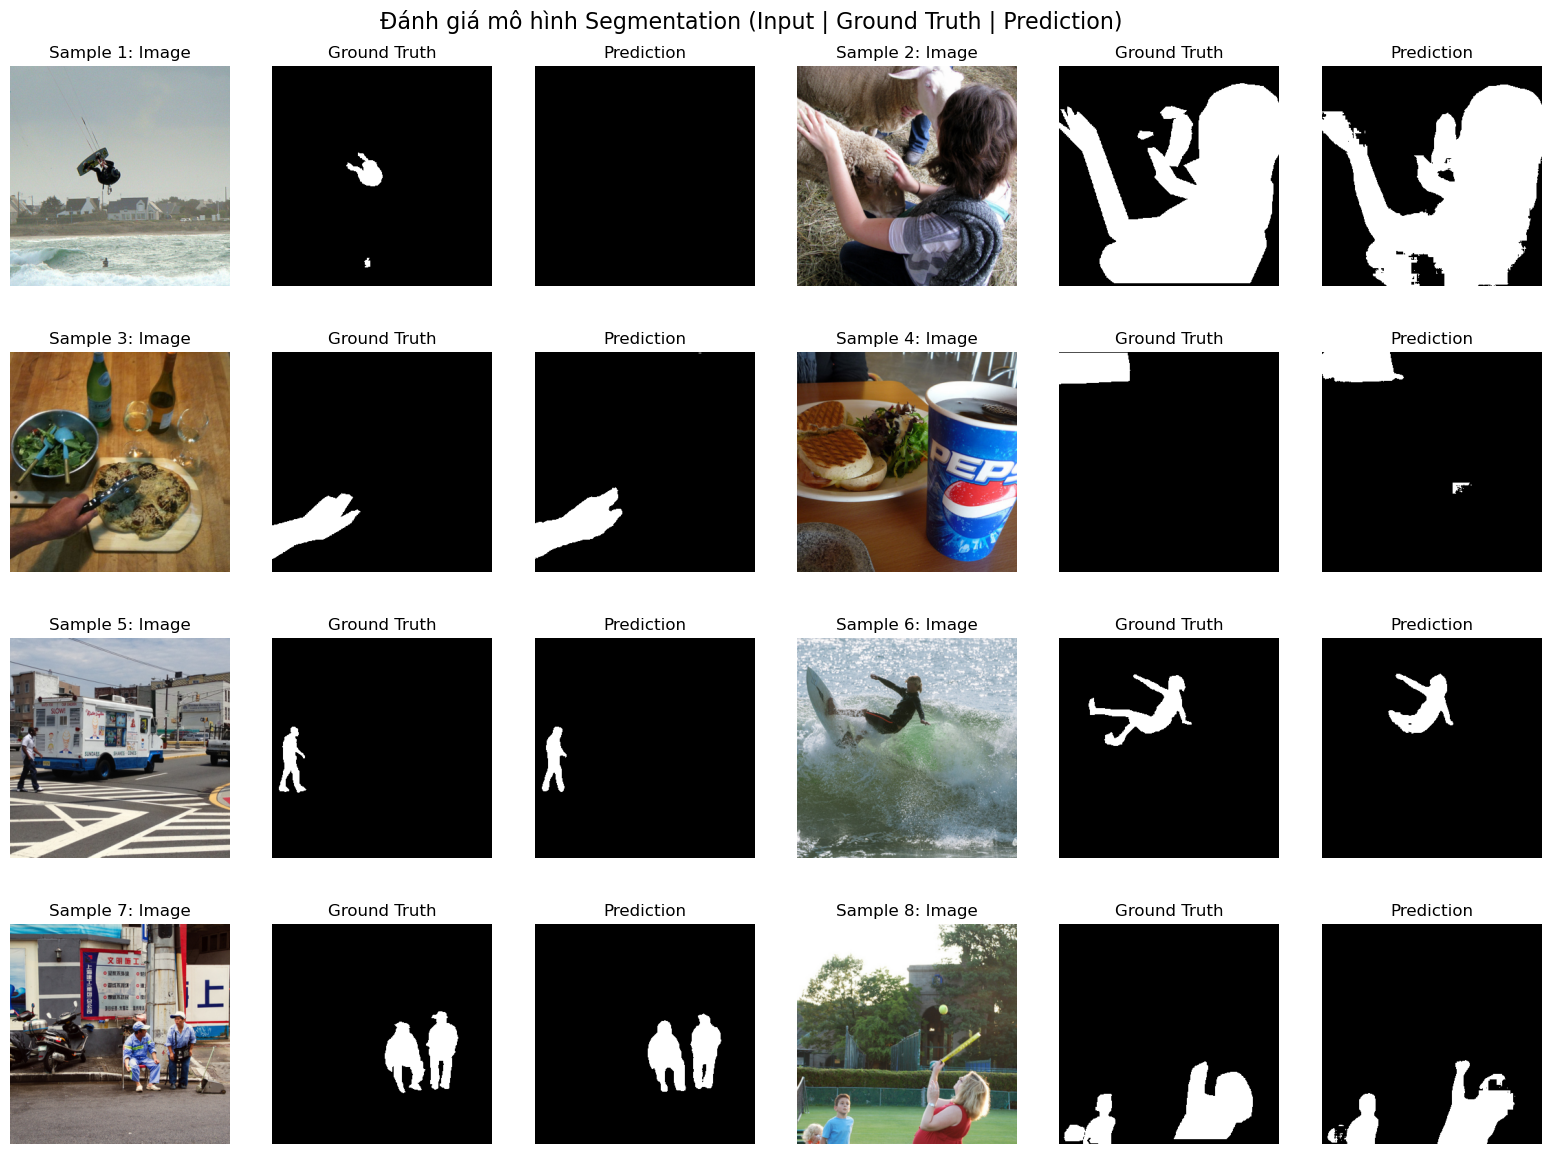

In [59]:
best_model_path = os.path.join(SAVE_MODEL_DIR, "best_unet_base.pth")
best_checkpoint = torch.load(best_model_path) 
model.load_state_dict(best_checkpoint['model_state_dict'])

print("\nĐang trực quan hóa kết quả...")
visualize_predictions(model, val_loader, device, num_samples=8)

In [60]:
def apply_color_mask(image, mask, color=(0.0, 1.0, 0.0), alpha=0.5):
    """
    Phủ một lớp màu bán trong suốt lên vùng có mask.
    - image: mảng numpy ảnh gốc (H, W, 3), giá trị [0, 1]
    - mask: mảng numpy nhị phân (H, W), giá trị 0 hoặc 1
    - color: tuple màu RGB (mặc định Xanh lá)
    - alpha: độ trong suốt (0.0 -> 1.0)
    """
    colored_image = image.copy()
    for c in range(3):
        colored_image[:, :, c] = np.where(
            mask > 0,
            image[:, :, c] * (1 - alpha) + alpha * color[c],
            image[:, :, c]
        )
    return np.clip(colored_image, 0, 1)

def visualize_predictions_colored(model, dataloader, device, num_samples=8):
    model.eval()
    samples_shown = 0
    
    fig, axes = plt.subplots(nrows=4, ncols=6, figsize=(20, 14))
    plt.subplots_adjust(wspace=0.1, hspace=0.3)
    
    inv_normalize = transforms.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )

    with torch.no_grad():
        for images, masks in dataloader:
            images = images.to(device)
            masks = masks.to(device)

            with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=device.type == 'cuda'):
                outputs = model(images)
            
            preds = torch.sigmoid(outputs) > 0.5

            images = images.cpu()
            masks = masks.cpu()
            preds = preds.cpu()

            for i in range(images.size(0)):
                if samples_shown >= num_samples:
                    break
                
                row = samples_shown // 2
                col_offset = (samples_shown % 2) * 3

                img = inv_normalize(images[i]).permute(1, 2, 0).numpy()
                img = np.clip(img, 0, 1)

                gt_mask = masks[i].squeeze().numpy()
                pred_mask = preds[i].squeeze().numpy()

                gt_overlay = apply_color_mask(img, gt_mask, color=(0.0, 1.0, 0.0), alpha=0.5)
                pred_overlay = apply_color_mask(img, pred_mask, color=(1.0, 0.0, 0.0), alpha=0.5)

                ax_img = axes[row, col_offset]
                ax_img.imshow(img)
                ax_img.set_title(f"Sample {samples_shown+1}")
                ax_img.axis('off')

                ax_gt = axes[row, col_offset + 1]
                ax_gt.imshow(gt_overlay)
                ax_gt.set_title("Truth (Green)")
                ax_gt.axis('off')

                ax_pred = axes[row, col_offset + 2]
                ax_pred.imshow(pred_overlay)
                ax_pred.set_title("Pred (Red)")
                ax_pred.axis('off')

                samples_shown += 1

            if samples_shown >= num_samples:
                break

    plt.suptitle("Đánh giá mô hình Segmentation (Overlay Màu)", fontsize=18, y=0.92, fontweight='bold')
    plt.show()


Đang trực quan hóa kết quả...


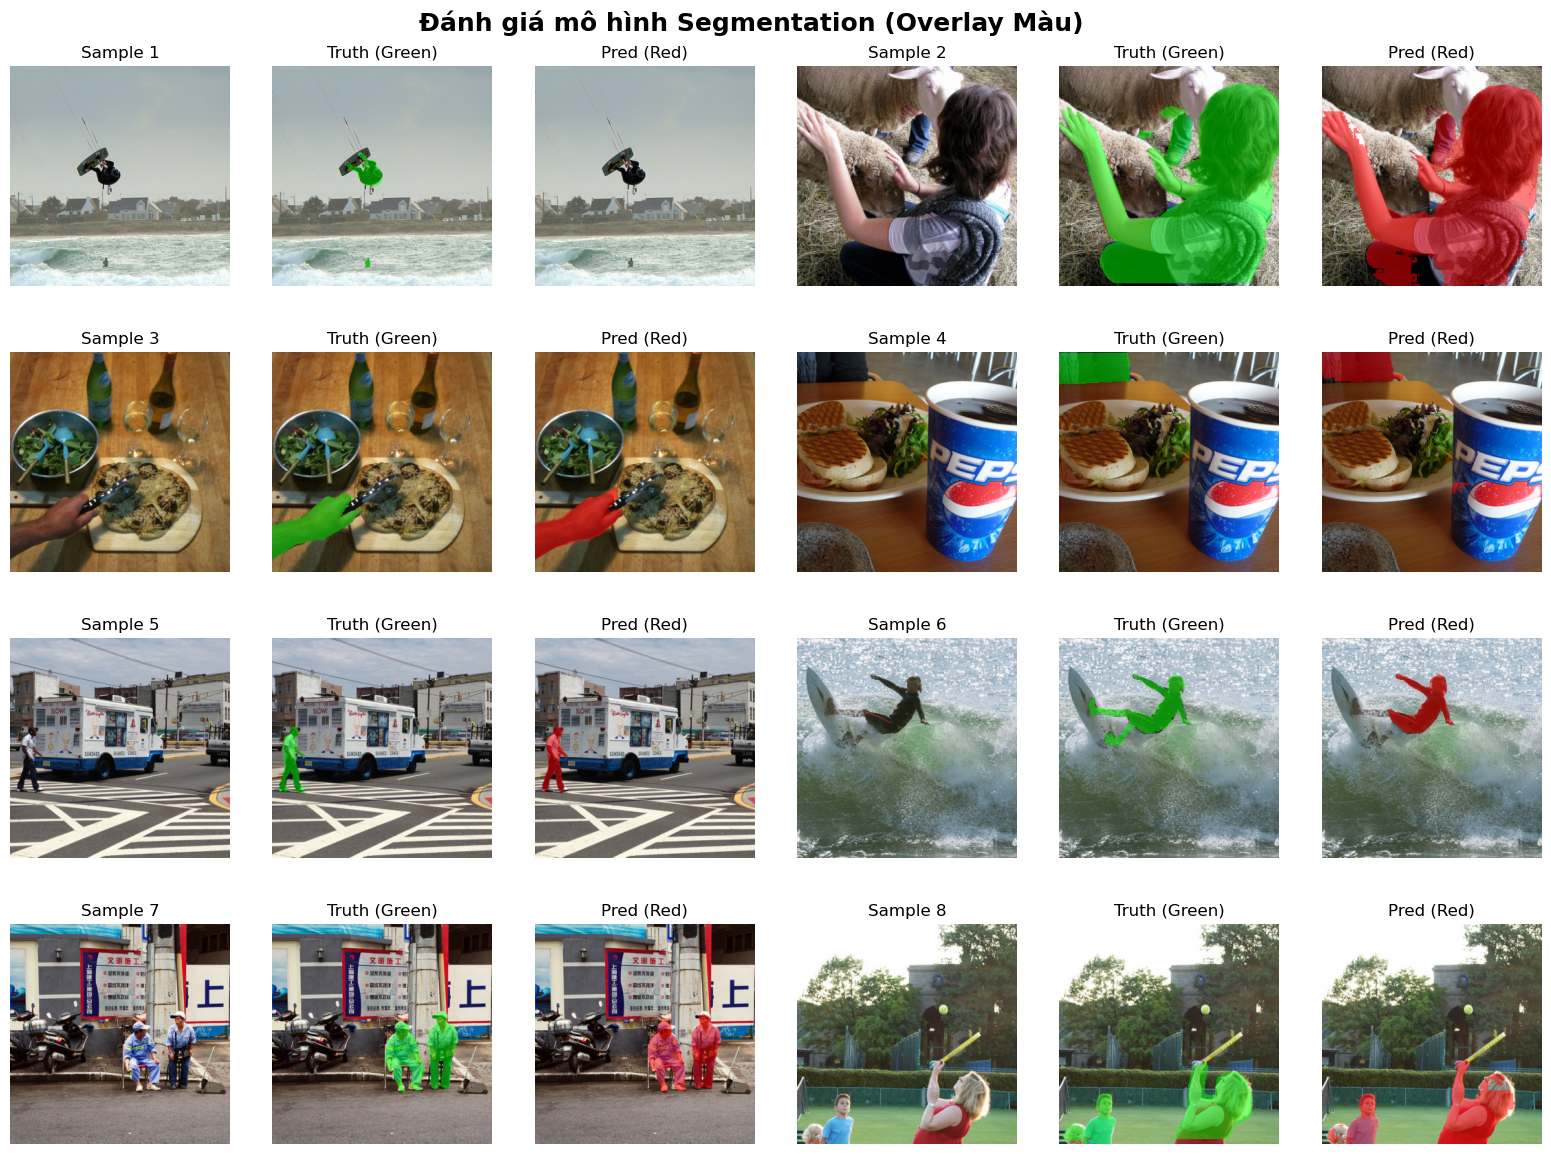

In [65]:
print("\nĐang trực quan hóa kết quả...")
visualize_predictions_colored(model, val_loader, device, num_samples=8)


Đang trực quan hóa kết quả...


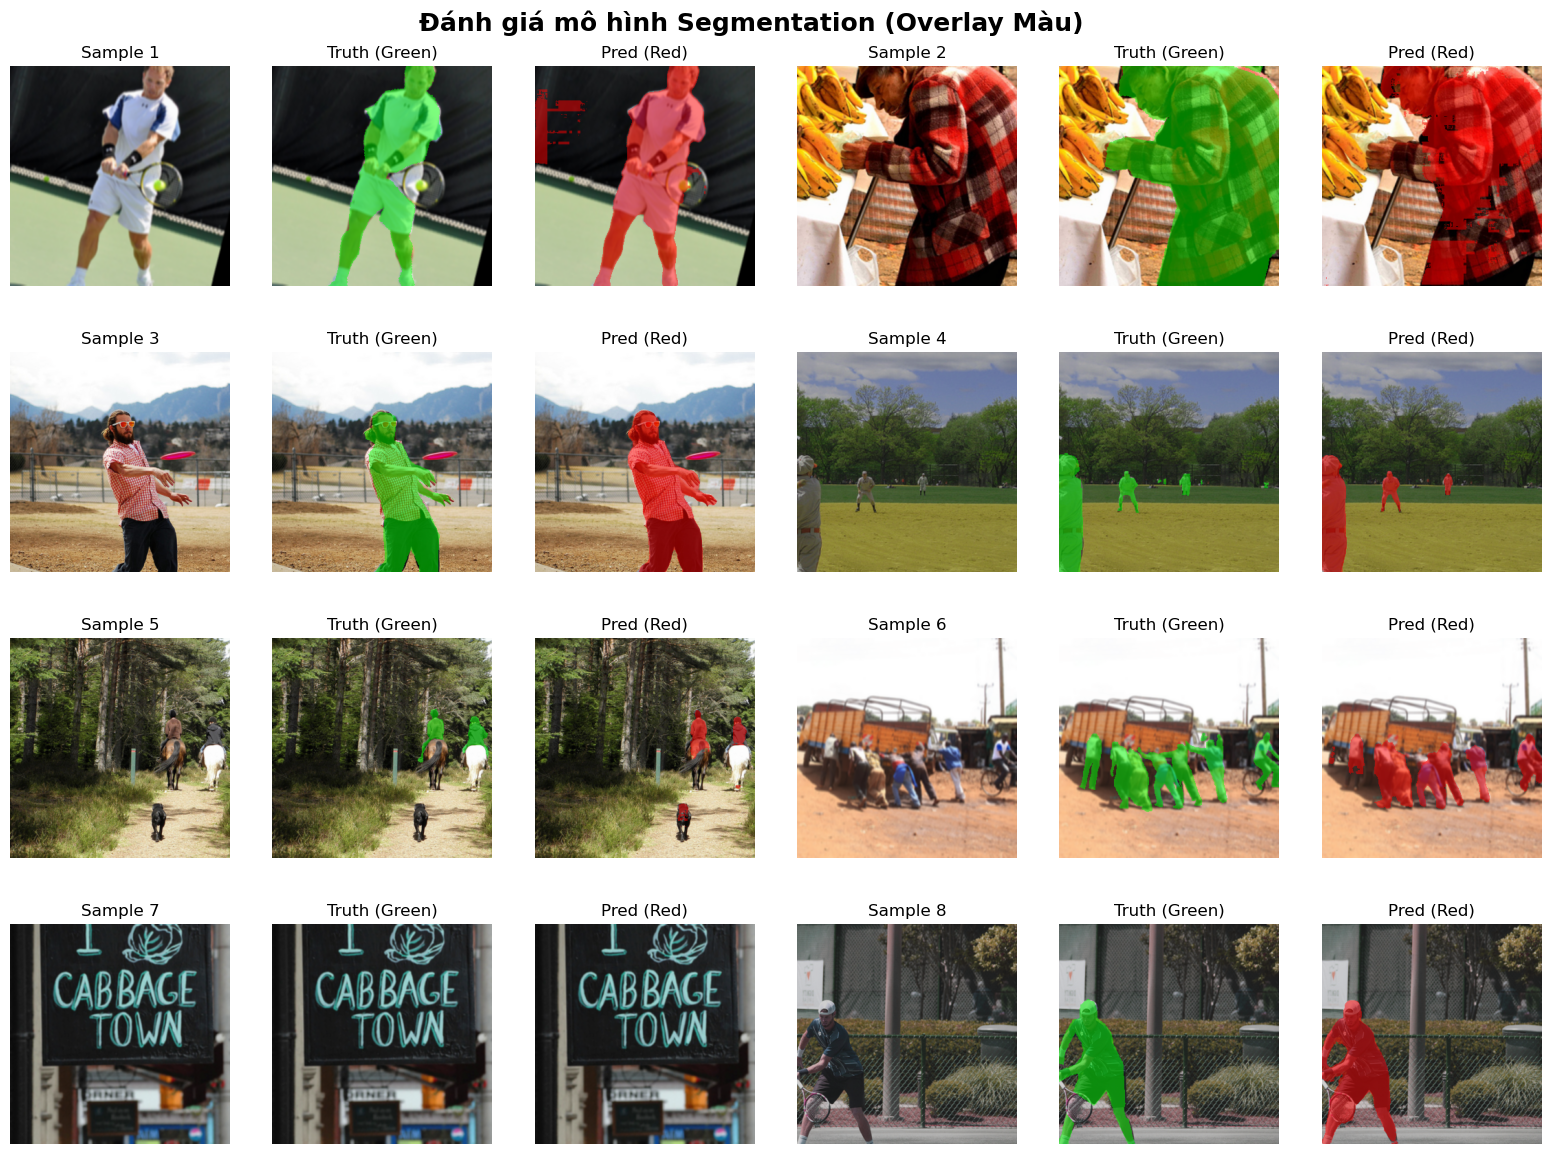

In [70]:
print("\nĐang trực quan hóa kết quả...")
visualize_predictions_colored(model, train_loader, device, num_samples=8)